# DCGAN

Adaptation du [code de François Chollet](https://keras.io/examples/generative/dcgan_overriding_train_step/) à l'architecture DCGAN.

Pour les GANs, comme pour les VAEs, on doit customiser la méthode `fit` de Keras. [Voir ici](https://keras.io/guides/customizing_what_happens_in_fit/) pour des détails sur ce sujet.

## Imports

In [1]:
import pathlib
from zipfile import ZipFile

import gdown
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as keras

## Téléchargement des données

In [2]:
pathlib.Path("celeba").mkdir(exist_ok=True)

url = "https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684"
output = "data.zip"
gdown.download(url, output, quiet=True)

with ZipFile("data.zip", "r") as zipobj:
  zipobj.extractall("celeba")

[Création d'un dataset](https://keras.io/api/preprocessing/image/#imagedatasetfromdirectory-function) depuis le dossier téléchargé, et normalisation des images vers l'intervalle $[0,1]$ :

In [3]:
dataset = keras.preprocessing.image_dataset_from_directory(
  "celeba", label_mode=None, image_size=(64, 64), batch_size=32
)
dataset = dataset.map(lambda x: x / 255.0)

Found 202599 files.


Affichons une image du dataset :

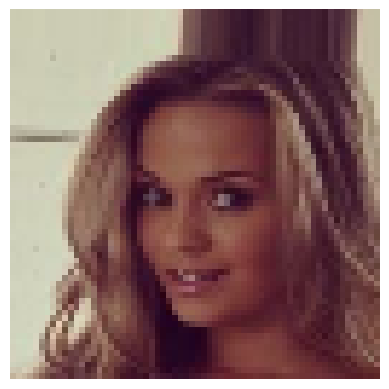

In [4]:
plt.axis("off")
plt.imshow(next(iter(dataset)).numpy()[0])
plt.show()

## Création du discriminateur

La tâche du discriminateur est de prédire un booléen à partir de l'image 64 × 64.

In [5]:
discriminator = keras.Sequential(
  [
    keras.Input(shape=(64, 64, 3)),
    keras.layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Conv2D(256, kernel_size=4, strides=2, padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Conv2D(512, kernel_size=4, strides=2, padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid"),
  ],
  name="discriminator",
)
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,321 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Création du générateur

La tâche du générateur est de créer une image 64 × 64 depuis un vecteur de bruit (ici de taille 128).

In [6]:
latent_dim = 128
generator = keras.Sequential(
  [
    keras.Input(shape=(latent_dim,)),
    keras.layers.Dense(4 * 4 * 1024),
    keras.layers.Reshape((4, 4, 1024)),
    keras.layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(negative_slope=0.2),
    keras.layers.Conv2DTranspose(
      3, kernel_size=4, strides=2, padding="same", activation="sigmoid"
    ),
  ],
  name="generator",
)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 512)      │     8,389,120 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,134,211 (50.10 MB)

 Trainable params: 13,132,419 (50.10 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Customisation de `train_step`

In [7]:
class GAN(keras.Model):
  def __init__(self, discriminator, generator, latent_dim):
    super().__init__()
    self.discriminator = discriminator
    self.generator = generator
    self.latent_dim = latent_dim

  def compile(self, d_optimizer, g_optimizer, loss_fn):
    super().compile()
    self.d_optimizer = d_optimizer
    self.g_optimizer = g_optimizer
    self.loss_fn = loss_fn
    self.d_loss_metric = keras.metrics.Mean(name="d_loss")
    self.g_loss_metric = keras.metrics.Mean(name="g_loss")

  @property
  def metrics(self):
    return [self.d_loss_metric, self.g_loss_metric]

  def train_step(self, real_images):
    # Sample random points in the latent space
    batch_size = tf.shape(real_images)[0]
    random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

    # Decode them to fake images
    generated_images = self.generator(random_latent_vectors)

    # Combine them with real images
    combined_images = tf.concat([generated_images, real_images], axis=0)

    # Assemble labels discriminating real from fake images
    labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
    # Add random noise to the labels - important trick!
    labels += 0.05 * tf.random.uniform(tf.shape(labels))

    # Train the discriminator
    with tf.GradientTape() as tape:
      predictions = self.discriminator(combined_images)
      d_loss = self.loss_fn(labels, predictions)
    grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
    self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

    # Sample random points in the latent space
    random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

    # Assemble labels that say "all real images"
    misleading_labels = tf.zeros((batch_size, 1))

    # Train the generator (note that we should *not* update the weights
    # of the discriminator)!
    with tf.GradientTape() as tape:
      predictions = self.discriminator(self.generator(random_latent_vectors))
      g_loss = self.loss_fn(misleading_labels, predictions)
    grads = tape.gradient(g_loss, self.generator.trainable_weights)
    self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

    # Update metrics
    self.d_loss_metric.update_state(d_loss)
    self.g_loss_metric.update_state(g_loss)
    return {
      "d_loss": self.d_loss_metric.result(),
      "g_loss": self.g_loss_metric.result(),
    }

## Création d'un callback pour voir les images générées pendant l'entraînement

In [8]:
class ImageGenerator(keras.callbacks.Callback):
  def __init__(self, num_img=3, latent_dim=128):
    self.num_img = num_img
    self.latent_dim = latent_dim

  def on_epoch_end(self, epoch, logs=None):
    output_dir = pathlib.Path("generated_imgs") / f"{epoch}"
    output_dir.mkdir(exist_ok=True, parents=True)
    random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
    generated_images = self.model.generator(random_latent_vectors)
    generated_images *= 255
    generated_images.numpy()
    for i in range(self.num_img):
      img = keras.preprocessing.image.array_to_img(generated_images[i])
      img.save(f"{output_dir}/{i}.png")

## Entraînement

In [9]:
epochs = 3  # In practice, use ~100 epochs

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
  d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
  g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
  loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(
  dataset,
  epochs=epochs,
  callbacks=[ImageGenerator(num_img=10, latent_dim=latent_dim)],
)

Epoch 1/3
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 450s 68ms/step - d_loss: 0.4659 - g_loss: 2.1208
Epoch 2/3
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 481s 67ms/step - d_loss: 0.5215 - g_loss: 1.7526
Epoch 3/3
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 422s 67ms/step - d_loss: 0.4520 - g_loss: 1.9412


Résultat après 30 epochs (la génération s'améliore encore après) :

![results](https://i.imgur.com/h5MtQZ7l.png)